### Police Use-of-Force & Socioeconomic Analysis (U.S.)
 Goal: Analyze patterns in fatal police shootings and how incident counts relate to socioeconomic indicators (income, poverty, education, demographics).
 Data: Washington Post police shootings database + U.S. Census city/state indicators (income, poverty, education, race).
 Key Questions:

 Which states and cities have the highest incident counts?

 How do poverty and education relate to incident counts at the state level?

 What demographic patterns appear in the data?

 How have incidents changed over time (2015–present)?
 Tools: Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
from collections import Counter

## Notebook Presentation


In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## Loading the data

In [3]:
df_hh_income = pd.read_csv("Median_Household_Income_2015.csv", encoding="windows-1252")
df_pct_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="windows-1252")
df_pct_completed_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="windows-1252")
df_share_race_city = pd.read_csv("Share_of_Race_By_City.csv", encoding="windows-1252")
df_fatalities = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# Preliminary Data Exploration



In [4]:
dfs = {
    "Fatalities": df_fatalities,
    "Income": df_hh_income,
    "Poverty": df_pct_poverty,
    "Education": df_pct_completed_hs,
    "Race": df_share_race_city
}

for name, df in dfs.items():
    print(f"{name} shape: {df.shape}")

Fatalities shape: (2535, 14)
Income shape: (29322, 3)
Poverty shape: (29329, 3)
Education shape: (29329, 3)
Race shape: (29268, 7)


In [5]:
for name, df in dfs.items():
    print(f"\n{name} columns:")
    print(df.columns.tolist())


Fatalities columns:
['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']

Income columns:
['Geographic Area', 'City', 'Median Income']

Poverty columns:
['Geographic Area', 'City', 'poverty_rate']

Education columns:
['Geographic Area', 'City', 'percent_completed_hs']

Race columns:
['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']


In [6]:
for name, df in dfs.items():
    print(f"\n{name}")
    print("Missing values:")
    print(df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())


Fatalities
Missing values:
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64
Duplicate rows: 0

Income
Missing values:
Geographic Area     0
City                0
Median Income      51
dtype: int64
Duplicate rows: 0

Poverty
Missing values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Duplicate rows: 0

Education
Missing values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
Duplicate rows: 0

Race
Missing values:
Geographic area          0
City                     0
share_white              0
share_black              0
s

## Data Cleaning - Checking for Missing Values and Duplicates



In [7]:
# Fatalities dataset: fill NaNs where 0 / Unknown makes sense
df_fatalities['armed'] = df_fatalities['armed'].fillna('Unknown')
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')
df_fatalities['flee'] = df_fatalities['flee'].fillna('Unknown')

# Age: keep NaN (don’t assume age = 0)
# Census datasets: numeric NaNs -> 0 (small or missing census entries)
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(0)
df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].fillna(0)
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].fillna(0)

In [8]:
df_fatalities = df_fatalities.drop_duplicates()
df_hh_income = df_hh_income.drop_duplicates()
df_pct_poverty = df_pct_poverty.drop_duplicates()
df_pct_completed_hs = df_pct_completed_hs.drop_duplicates()
df_share_race_city = df_share_race_city.drop_duplicates()

# Charting the Poverty Rate in each US State



In [9]:
# This makes sure poverty_rate is numeric 
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')

# This calculates average poverty rate by state
state_poverty = (
    df_pct_poverty
    .groupby('Geographic Area', as_index=False)['poverty_rate']
    .mean()
    .sort_values('poverty_rate', ascending=False)
)

state_poverty.head()

,Geographic Area,poverty_rate
25,MS,26.88
3,AZ,25.67
10,GA,23.78
32,NM,23.08
2,AR,22.96


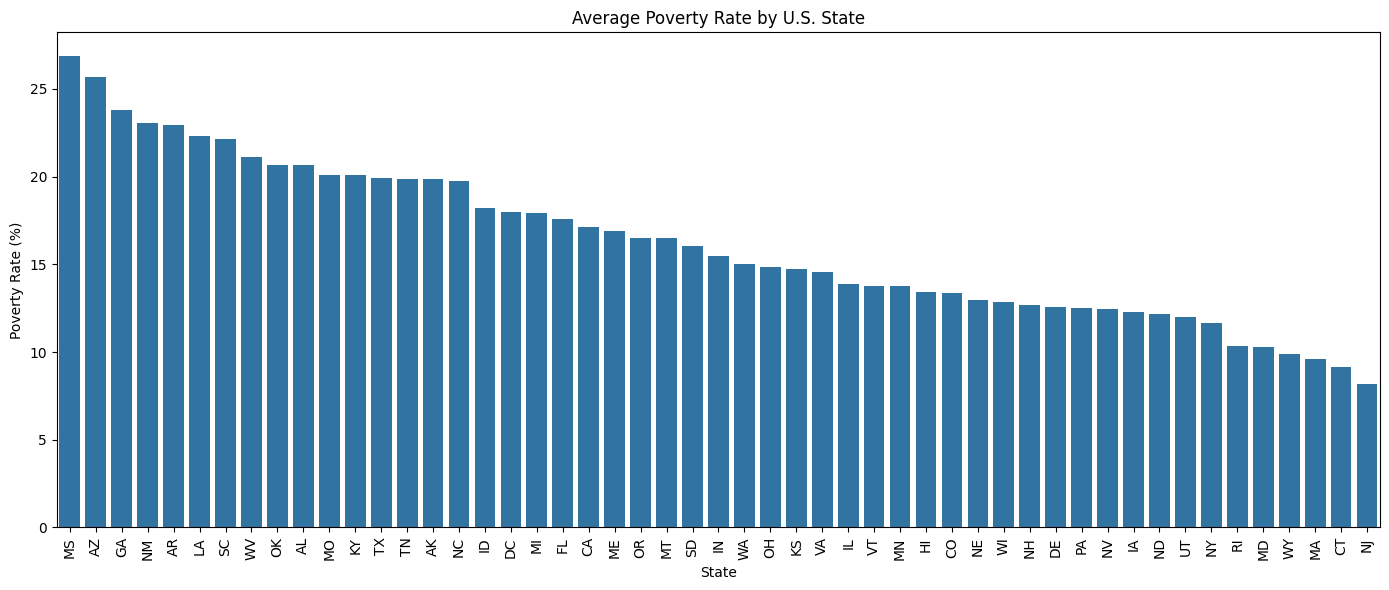

In [10]:
plt.figure(figsize=(14, 6))
sns.barplot(data=state_poverty, x='Geographic Area', y='poverty_rate')

plt.xticks(rotation=90)
plt.title('Average Poverty Rate by U.S. State')
plt.xlabel('State')
plt.ylabel('Poverty Rate (%)')
plt.tight_layout()
plt.show()

# Charting the High School Graduation Rate by US State



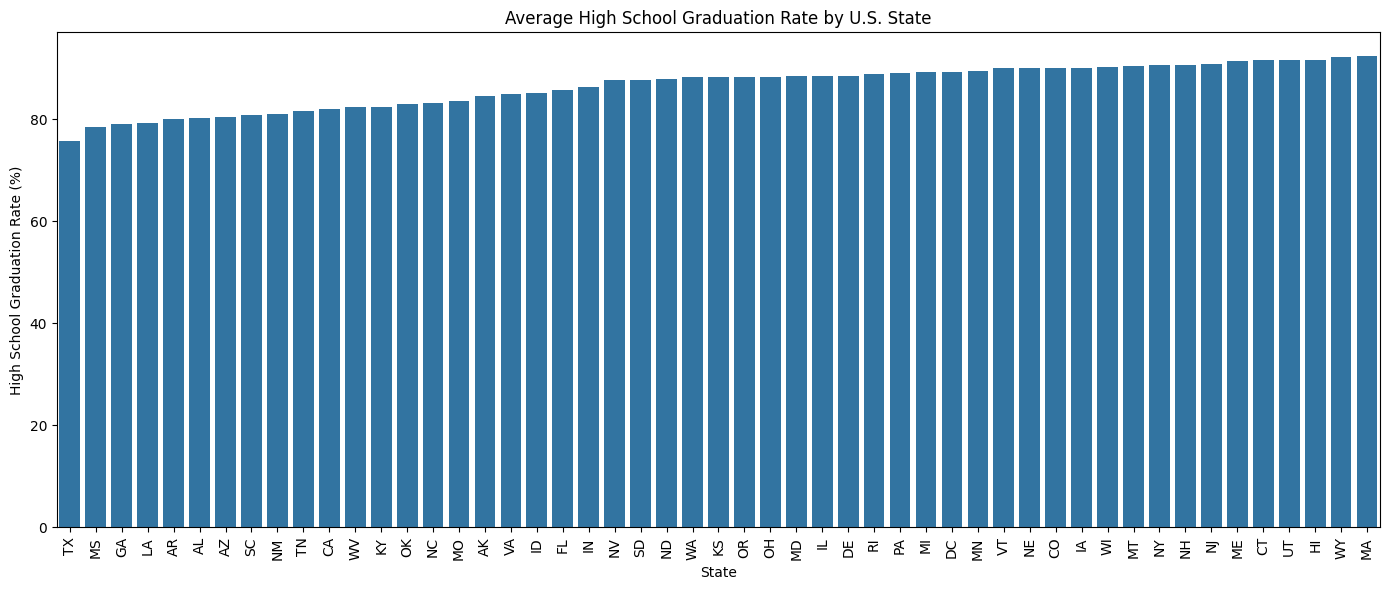

In [11]:
# Ensure graduation rate is numeric
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(
    df_pct_completed_hs['percent_completed_hs'], errors='coerce'
)

# Calculate average high school graduation rate by state (ascending)
state_hs_grad = (
    df_pct_completed_hs
    .groupby('Geographic Area', as_index=False)['percent_completed_hs']
    .mean()
    .sort_values('percent_completed_hs', ascending=True)
)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=state_hs_grad,
    x='Geographic Area',
    y='percent_completed_hs'
)

plt.xticks(rotation=90)
plt.title('Average High School Graduation Rate by U.S. State')
plt.xlabel('State')
plt.ylabel('High School Graduation Rate (%)')
plt.tight_layout()
plt.show()

# Visualizing the Relationship between Poverty Rates and High School Graduation Rates

### A line chart with two y-axes to show if the ratios of poverty and high school graduation move together.  

In [12]:
# Ensure both columns are numeric
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(
    df_pct_completed_hs['percent_completed_hs'], errors='coerce'
)

# Aggregate by state
state_poverty = (
    df_pct_poverty
    .groupby('Geographic Area', as_index=False)['poverty_rate']
    .mean()
)

state_grad = (
    df_pct_completed_hs
    .groupby('Geographic Area', as_index=False)['percent_completed_hs']
    .mean()
)

# Merge the two datasets on state
state_edu_poverty = pd.merge(
    state_poverty,
    state_grad,
    on='Geographic Area'
)

# Sort by poverty rate for cleaner visualization
state_edu_poverty = state_edu_poverty.sort_values('poverty_rate')

state_edu_poverty.head()


,Geographic Area,poverty_rate,percent_completed_hs
31,NJ,8.19,90.85
6,CT,9.14,91.59
19,MA,9.59,92.40
50,WY,9.89,92.10
20,MD,10.31,88.42


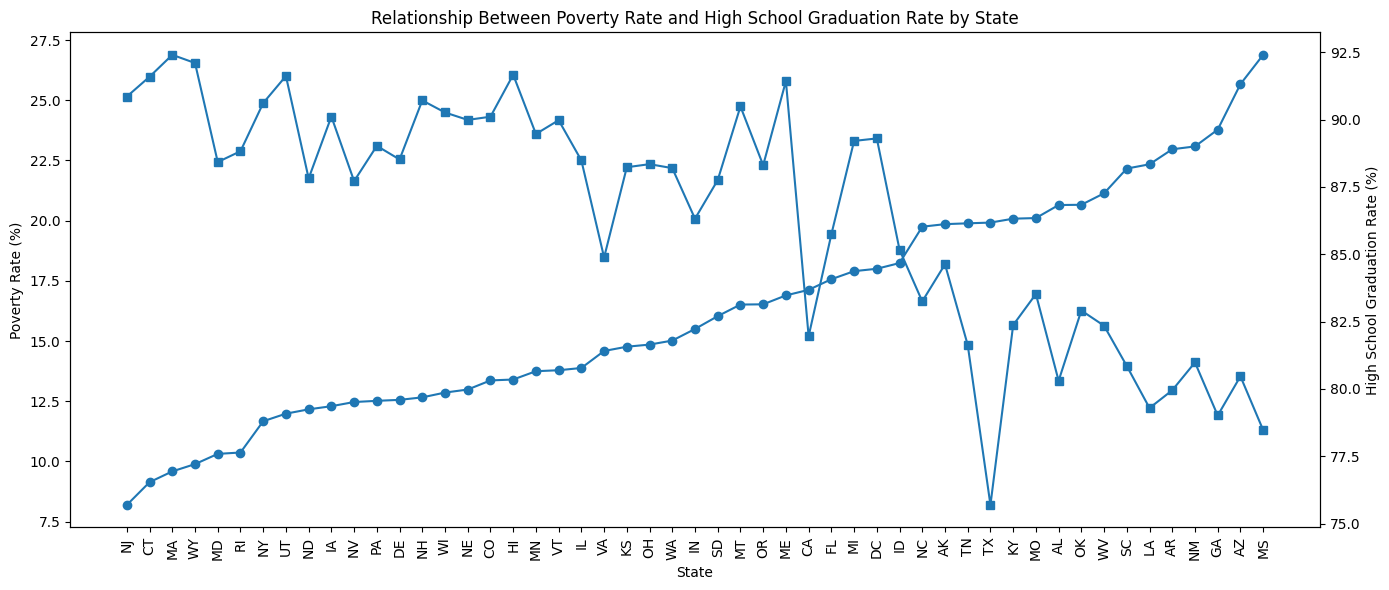

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Poverty rate (left y-axis)
ax1.plot(
    state_edu_poverty['Geographic Area'],
    state_edu_poverty['poverty_rate'],
    marker='o'
)
ax1.set_xlabel('State')
ax1.set_ylabel('Poverty Rate (%)')
ax1.tick_params(axis='x', rotation=90)

# Graduation rate (right y-axis)
ax2 = ax1.twinx()
ax2.plot(
    state_edu_poverty['Geographic Area'],
    state_edu_poverty['percent_completed_hs'],
    marker='s'
)
ax2.set_ylabel('High School Graduation Rate (%)')

plt.title('Relationship Between Poverty Rate and High School Graduation Rate by State')
plt.tight_layout()
plt.show()

### Visualization using Seaborn .jointplot() with KDE and/or scatter plot 

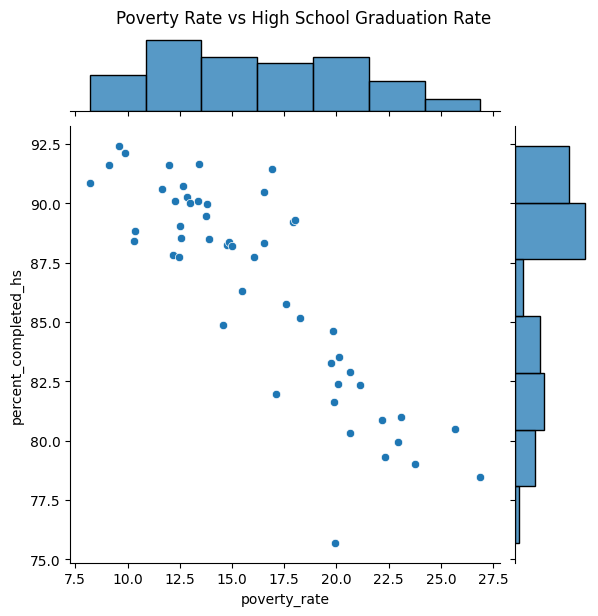

In [14]:
sns.jointplot(
    data=state_edu_poverty,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='scatter'
)
plt.suptitle(
    'Poverty Rate vs High School Graduation Rate',
    y=1.02
)
plt.show()

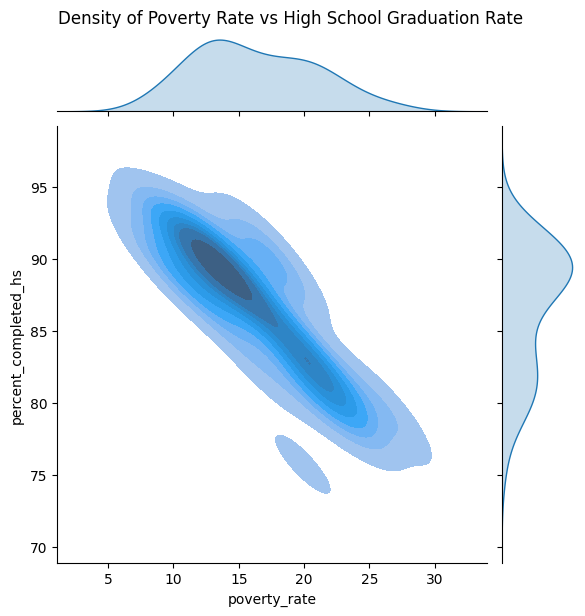

In [15]:
sns.jointplot(
    data=state_edu_poverty,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='kde',
    fill=True
)
plt.suptitle(
    'Density of Poverty Rate vs High School Graduation Rate',
    y=1.02
)
plt.show()

### Seaborn's .regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

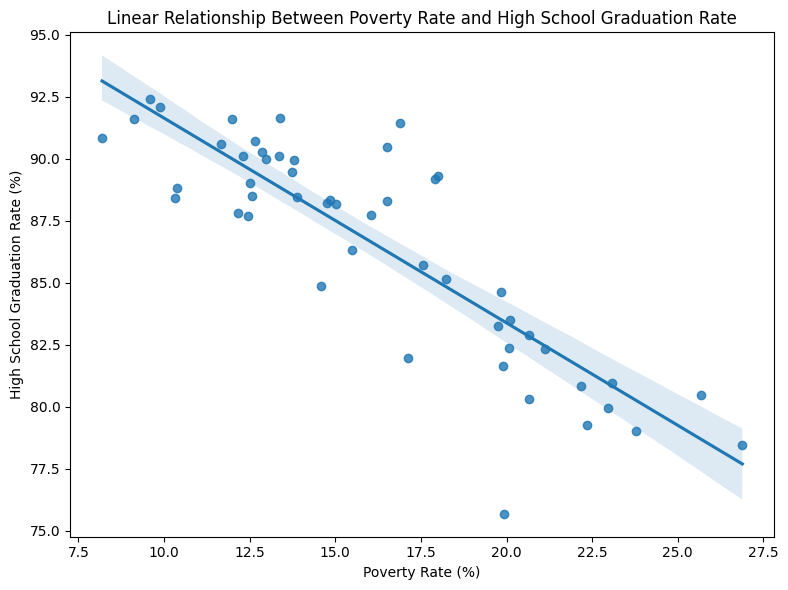

In [16]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=state_edu_poverty,
    x='poverty_rate',
    y='percent_completed_hs'
)

plt.title('Linear Relationship Between Poverty Rate and High School Graduation Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('High School Graduation Rate (%)')
plt.tight_layout()
plt.show()

### Racial composition by state

In [17]:
# Make sure race share columns are numeric
race_cols = [
    'share_white',
    'share_black',
    'share_hispanic',
    'share_asian',
    'share_native_american'
]

for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(
        df_share_race_city[col], errors='coerce'
    )

# Aggregate by state
state_race = (
    df_share_race_city
    .groupby('Geographic area', as_index=False)[race_cols]
    .mean()
)

state_race.head()

,Geographic area,share_white,share_black,share_hispanic,share_asian,share_native_american
0,AK,45.65,0.57,2.15,1.39,45.86
1,AL,72.51,23.32,2.98,0.48,0.66
2,AR,78.45,16.30,4.27,0.48,0.76
3,AZ,59.93,0.95,20.14,0.73,28.59
4,CA,71.87,2.69,29.65,5.57,1.72


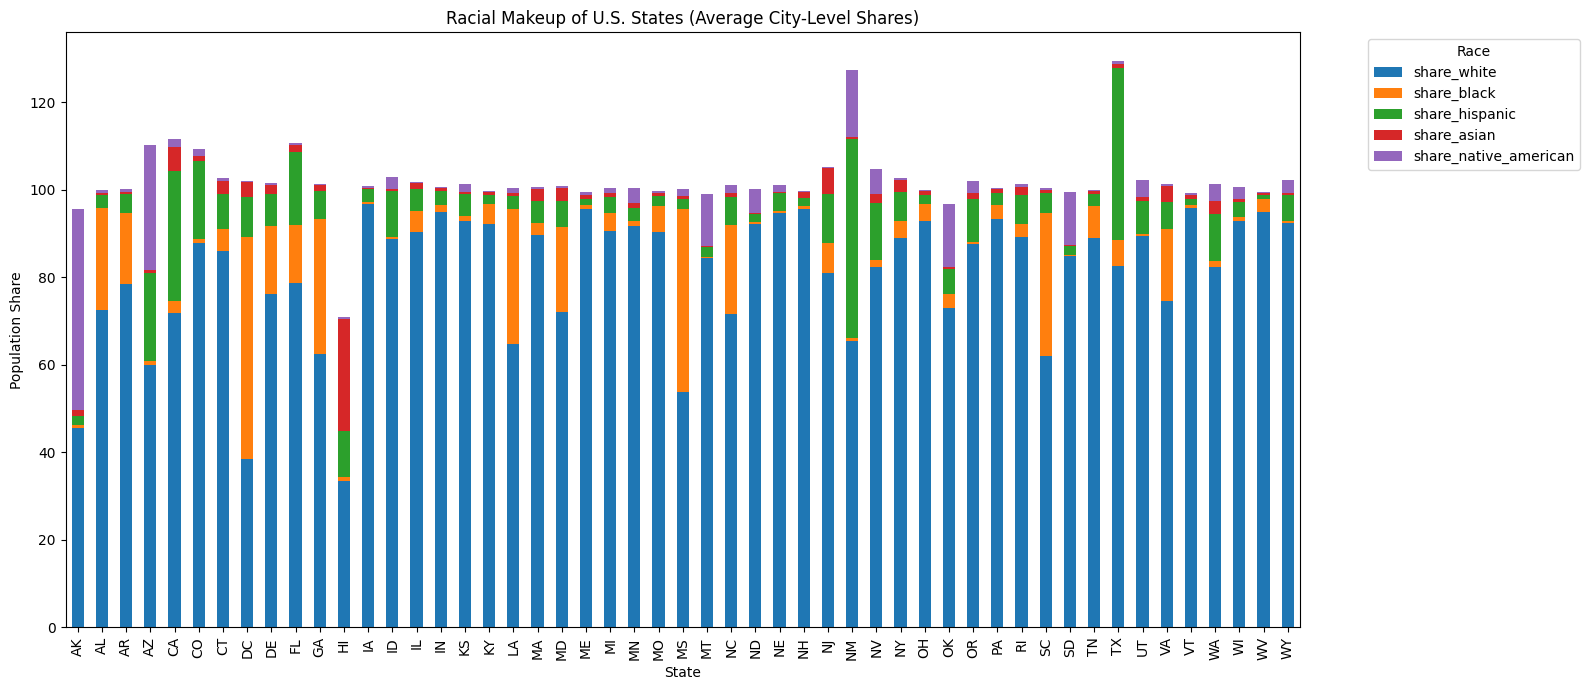

In [18]:
# Set state as index for plotting
state_race_plot = state_race.set_index('Geographic area')

# Plot stacked bar chart
state_race_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 7)
)

plt.title('Racial Makeup of U.S. States (Average City-Level Shares)')
plt.xlabel('State')
plt.ylabel('Population Share')
plt.xticks(rotation=90)
plt.legend(
    title='Race',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


#  Donut Chart of People Killed by Race



In [19]:
# Count number of people killed by race
race_counts = df_fatalities['race'].value_counts()

race_counts

race
W          1201
B           618
H           423
Unknown     195
A            39
N            31
O            28
Name: count, dtype: int64

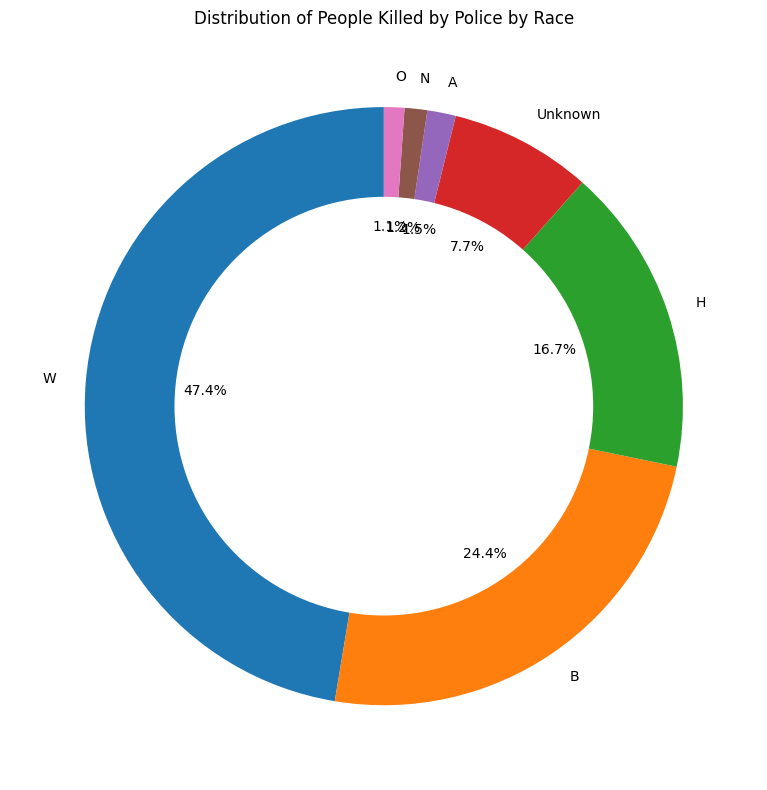

In [20]:
plt.figure(figsize=(8, 8))

plt.pie(
    race_counts,
    labels=race_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

# Draw a circle to make it a donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Distribution of People Killed by Police by Race')
plt.tight_layout()
plt.show()

#  Chart Comparing the Total Number of Deaths of Men and Women



In [21]:
# Count total deaths by gender
gender_counts = df_fatalities['gender'].value_counts()

gender_counts

gender
M    2428
F     107
Name: count, dtype: int64

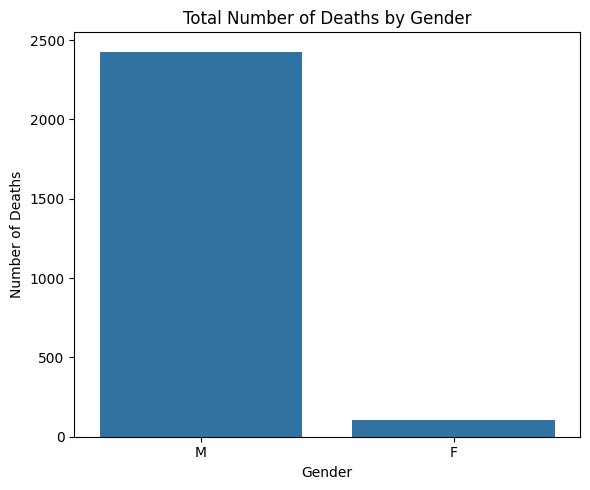

In [22]:
plt.figure(figsize=(6, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title('Total Number of Deaths by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Deaths')
plt.tight_layout()
plt.show()

#  Box Plot Showing the Age and Manner of Death



In [23]:
# Selecting relevant columns and drop missing ages
age_manner_gender = df_fatalities[['age', 'gender', 'manner_of_death']].dropna(subset=['age'])

age_manner_gender.head()

,age,gender,manner_of_death
0,53.00,M,shot
1,47.00,M,shot
2,23.00,M,shot and Tasered
3,32.00,M,shot
4,39.00,M,shot


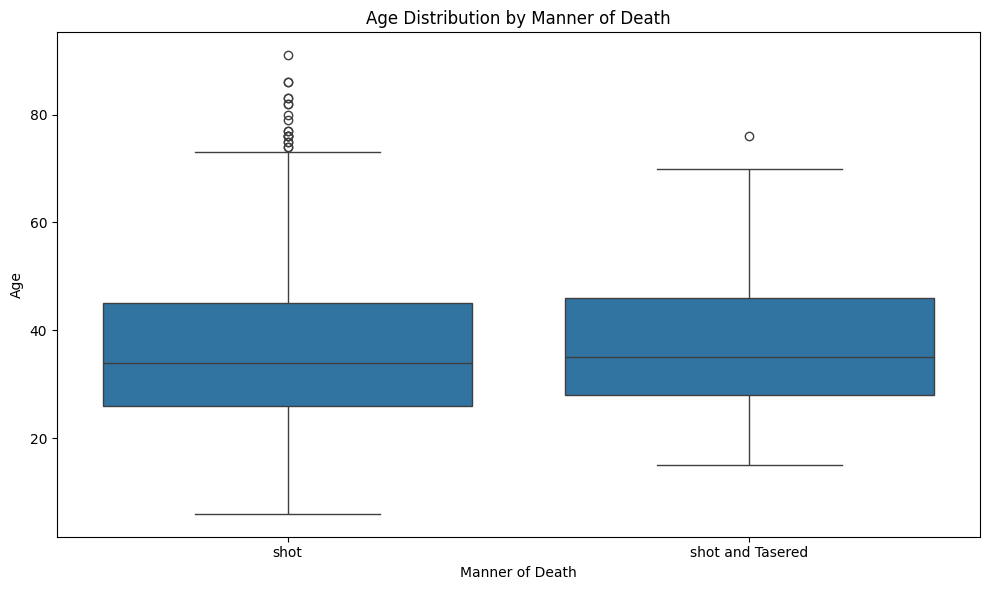

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=age_manner_gender,
    x='manner_of_death',
    y='age'
)

plt.title('Age Distribution by Manner of Death')
plt.xlabel('Manner of Death')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

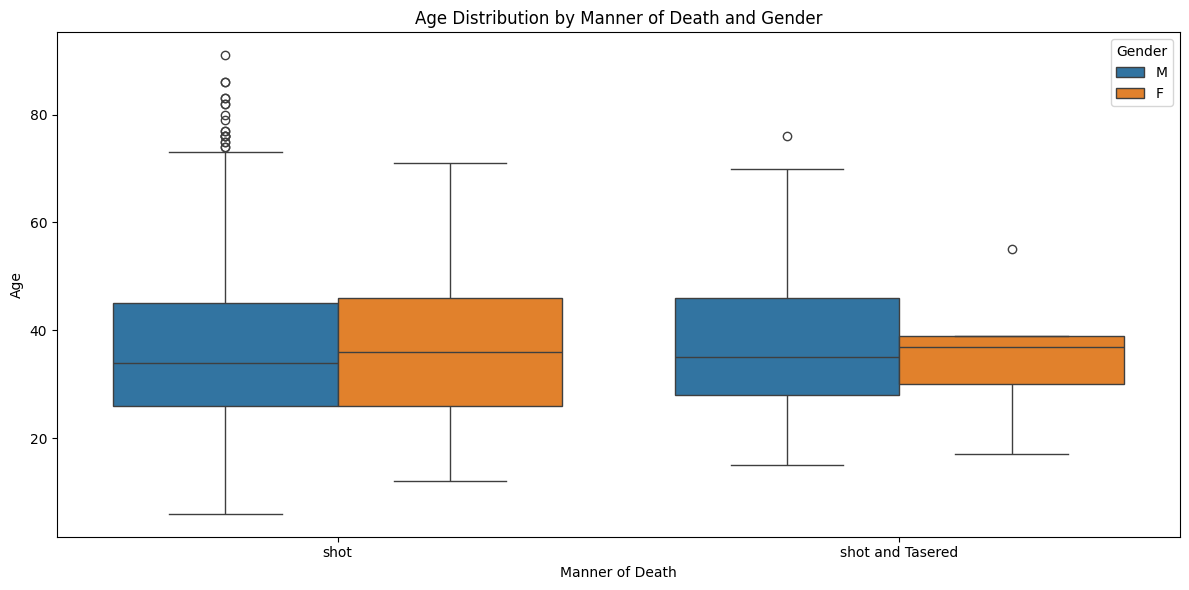

In [25]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=age_manner_gender,
    x='manner_of_death',
    y='age',
    hue='gender'
)

plt.title('Age Distribution by Manner of Death and Gender')
plt.xlabel('Manner of Death')
plt.ylabel('Age')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Armed vs unarmed

In [26]:
# Count armed vs unarmed
armed_counts = df_fatalities['armed'].value_counts()

# Create armed vs unarmed grouping
armed_status = df_fatalities['armed'].apply(
    lambda x: 'Unarmed' if x == 'unarmed' else 'Armed'
)

armed_status_counts = armed_status.value_counts()

# Calculate percentages
armed_status_percent = armed_status_counts / armed_status_counts.sum() * 100

armed_status_counts, armed_status_percent

(armed
 Armed      2364
 Unarmed     171
 Name: count, dtype: int64,
 armed
 Armed     93.25
 Unarmed    6.75
 Name: count, dtype: float64)

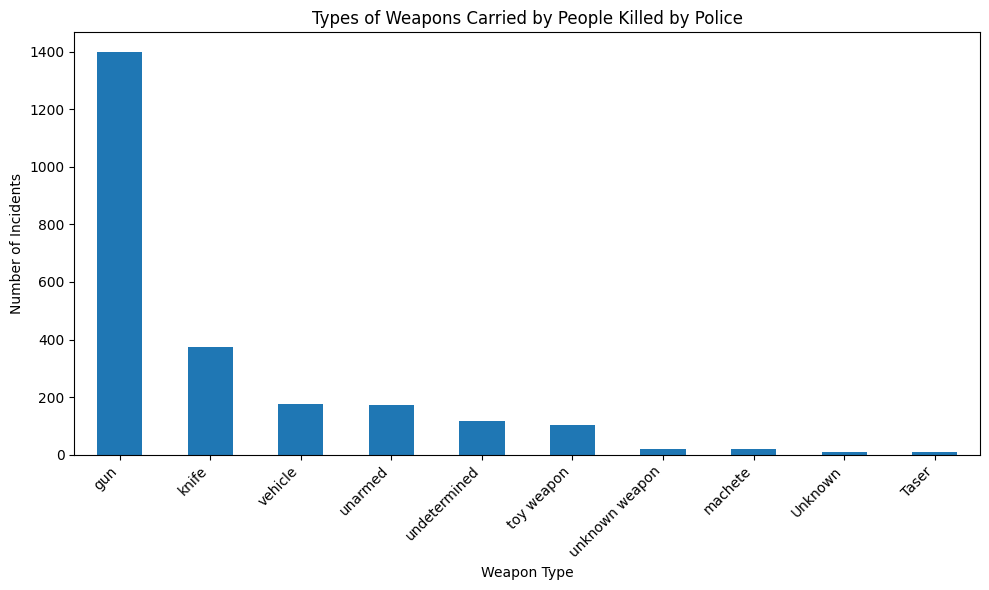

In [27]:
plt.figure(figsize=(10, 6))

df_fatalities['armed'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Types of Weapons Carried by People Killed by Police')
plt.xlabel('Weapon Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

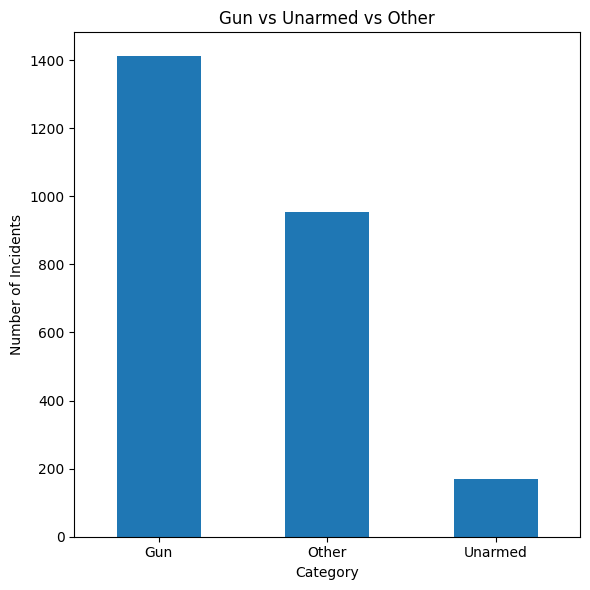

armed
Gun        1411
Other       953
Unarmed     171
Name: count, dtype: int64

In [28]:
gun_vs_unarmed = df_fatalities['armed'].apply(
    lambda x: 'Gun' if 'gun' in str(x).lower() else 'Unarmed' if x == 'unarmed' else 'Other'
)

gun_vs_unarmed_counts = gun_vs_unarmed.value_counts()

plt.figure(figsize=(6, 6))
gun_vs_unarmed_counts.plot(kind='bar')

plt.title('Gun vs Unarmed vs Other')
plt.xlabel('Category')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gun_vs_unarmed_counts

# age they were killed

In [29]:
# Drop missing ages first
ages = df_fatalities['age'].dropna()

under_25 = (ages < 25).sum()
total = ages.count()

percentage_under_25 = (under_25 / total) * 100

percentage_under_25

np.float64(18.307567127746136)

#  histogram and KDE plot that shows the distribution of ages of the people killed by police. 

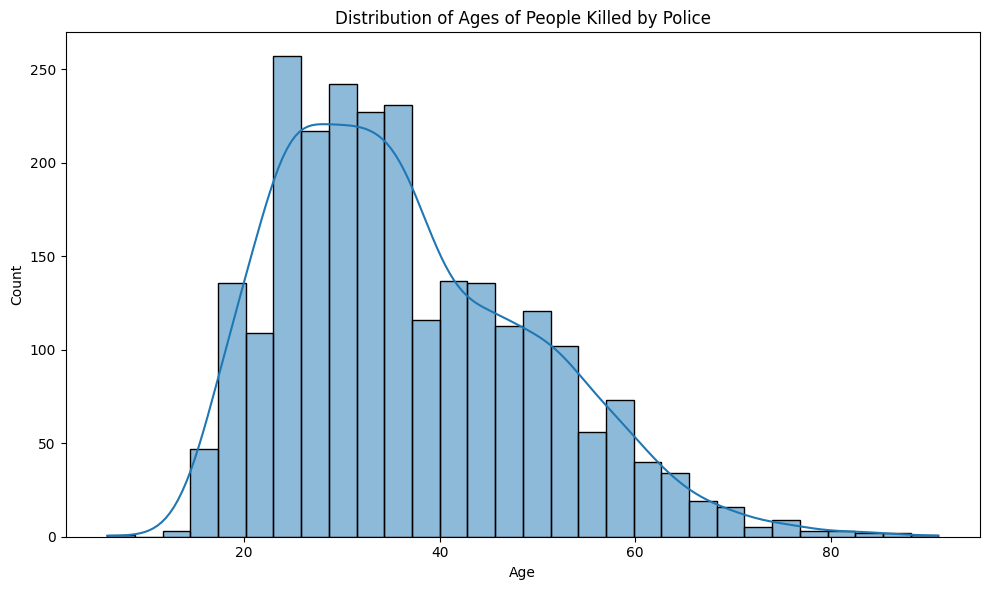

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df_fatalities['age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Ages of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### A separate KDE plot for each race. 

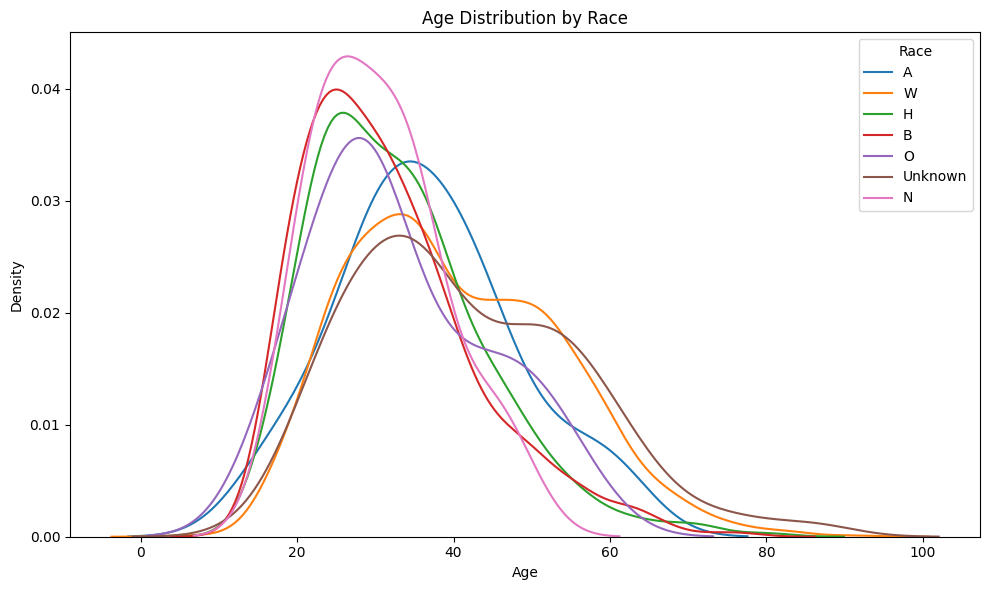

In [31]:
plt.figure(figsize=(10, 6))

for race in df_fatalities['race'].dropna().unique():
    sns.kdeplot(
        df_fatalities[df_fatalities['race'] == race]['age'].dropna(),
        label=race,
        fill=False
    )

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Race')
plt.tight_layout()
plt.show()

# Race of People Killed

### A chart that shows the total number of people killed by race. 

In [32]:
race_counts = df_fatalities['race'].value_counts()
race_counts

race
W          1201
B           618
H           423
Unknown     195
A            39
N            31
O            28
Name: count, dtype: int64

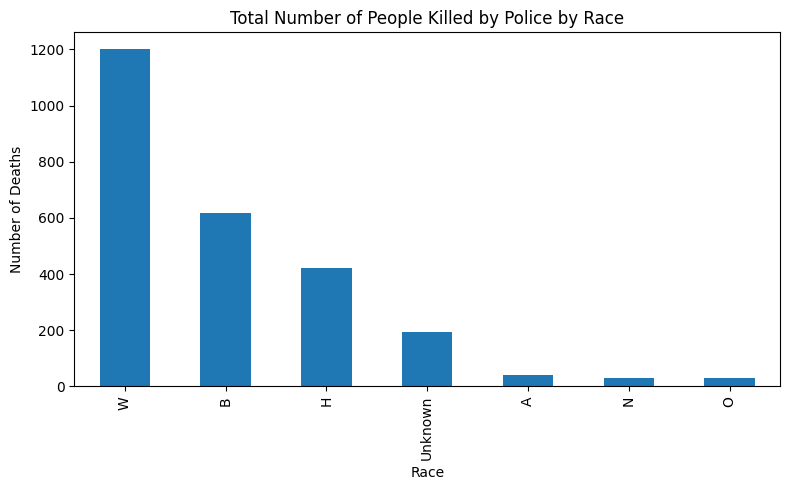

In [33]:
plt.figure(figsize=(8, 5))
race_counts.plot(kind='bar')
plt.title('Total Number of People Killed by Police by Race')
plt.xlabel('Race')
plt.ylabel('Number of Deaths')
plt.tight_layout()
plt.show()

# Mental Illness and Police Killings



In [34]:
# Count total cases
total_cases = len(df_fatalities)

# Count cases where signs of mental illness were reported
mental_illness_counts = df_fatalities['signs_of_mental_illness'].value_counts()

# Calculate percentage
mental_illness_percentage = (mental_illness_counts[True] / total_cases) * 100

mental_illness_counts, mental_illness_percentage

(signs_of_mental_illness
 False    1902
 True      633
 Name: count, dtype: int64,
 np.float64(24.970414201183434))

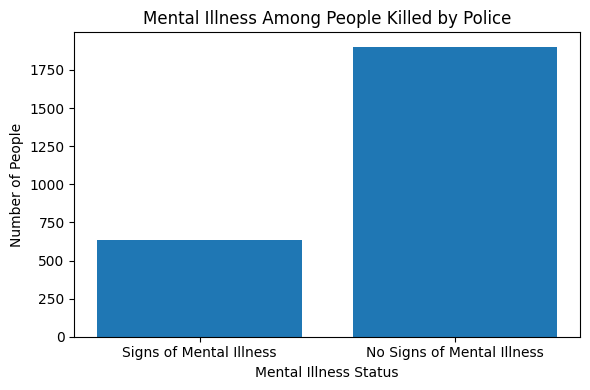

In [35]:


labels = ['Signs of Mental Illness', 'No Signs of Mental Illness']
values = [
    mental_illness_counts[True],
    mental_illness_counts[False]
]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title('Mental Illness Among People Killed by Police')
plt.ylabel('Number of People')
plt.xlabel('Mental Illness Status')
plt.tight_layout()
plt.show()

# 

# A chart ranking the top 10 cities with the most police killings. 

In [36]:
# Count police killings by city and get top 10
top_cities = df_fatalities['city'].value_counts().head(10)

top_cities

city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Austin         18
Miami          18
St. Louis      15
Name: count, dtype: int64

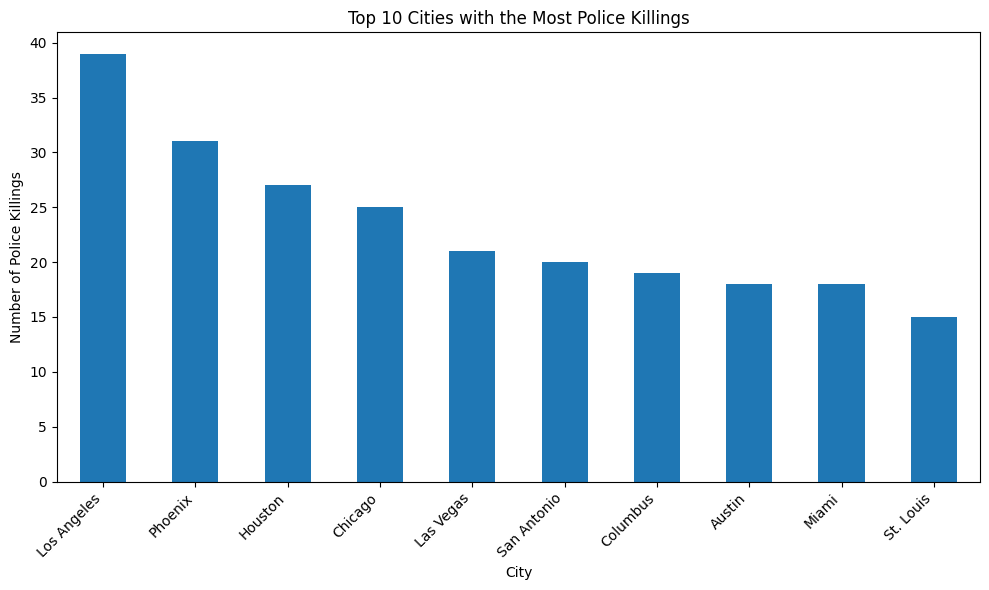

In [37]:


plt.figure(figsize=(10, 6))
top_cities.plot(kind='bar')
plt.title('Top 10 Cities with the Most Police Killings')
plt.xlabel('City')
plt.ylabel('Number of Police Killings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Rate of Death by Race

 

In [38]:
#  top 10 cities by total police killings
top_10_cities = df_fatalities['city'].value_counts().head(10).index

# Filter dataset to only top 10 cities
df_top_cities = df_fatalities[df_fatalities['city'].isin(top_10_cities)]

# Count killings by city and race
city_race_counts = (
    df_top_cities
    .groupby(['city', 'race'])
    .size()
    .reset_index(name='count')
)

# Calculate total killings per city
city_totals = (
    city_race_counts
    .groupby('city')['count']
    .sum()
    .reset_index(name='total')
)

# Merge totals back
city_race_rates = city_race_counts.merge(city_totals, on='city')

# Compute rate (share) by race for each city
city_race_rates['rate'] = city_race_rates['count'] / city_race_rates['total']

city_race_rates.head()

,city,race,count,total,rate
0,Austin,B,3,18,0.17
1,Austin,H,2,18,0.11
2,Austin,W,13,18,0.72
3,Chicago,B,21,25,0.84
4,Chicago,H,1,25,0.04


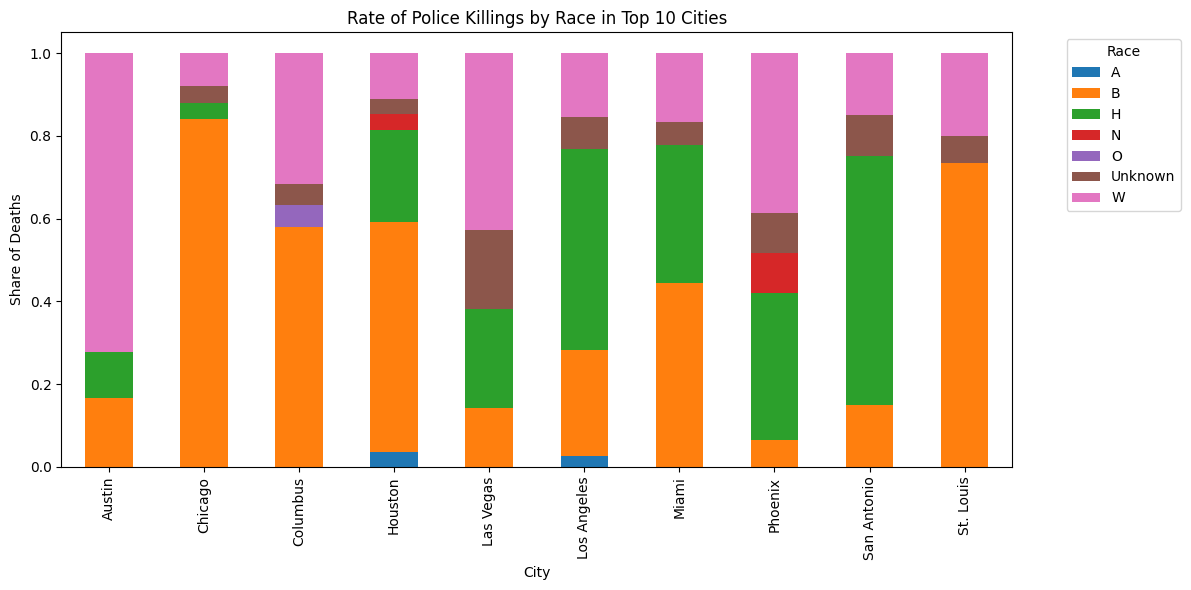

In [39]:


# Pivot table for plotting
pivot_rates = city_race_rates.pivot(
    index='city',
    columns='race',
    values='rate'
).fillna(0)

# Plot stacked bar chart
pivot_rates.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Rate of Police Killings by Race in Top 10 Cities')
plt.ylabel('Share of Deaths')
plt.xlabel('City')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# A Choropleth Map of Police Killings by US State



In [40]:
# Count police killings by state
state_killings = df_fatalities['state'].value_counts().reset_index()
state_killings.columns = ['state', 'killings']

state_killings.head()

,state,killings
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79


In [41]:


fig = px.choropleth(
    state_killings,
    locations='state',
    locationmode='USA-states',
    color='killings',
    color_continuous_scale='Reds',
    scope='usa',
    title='Police Killings by U.S. State'
)

pio.renderers.default = "browser"
fig.show()

# Number of Police Killings Over Time



In [42]:
df_fatalities['date'] = pd.to_datetime(
    df_fatalities['date'],
    format='%Y-%m-%d',
    errors='coerce'
)

df_fatalities['year'] = df_fatalities['date'].dt.year

In [43]:
# Count number of police killings per year
killings_by_year = (
    df_fatalities
    .dropna(subset=['year'])
    .groupby('year')
    .size()
    .reset_index(name='killings')
)

killings_by_year

,year,killings


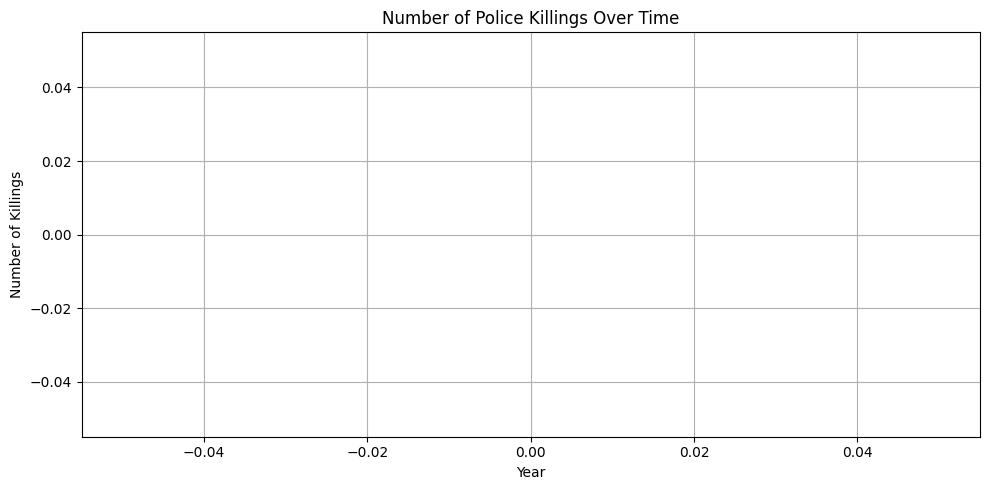

In [44]:


plt.figure(figsize=(10, 5))
plt.plot(
    killings_by_year['year'],
    killings_by_year['killings'],
    marker='o'
)

plt.title('Number of Police Killings Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Killings')
plt.grid(True)
plt.tight_layout()
plt.show()

## Key Takeaways

Fatal police shootings are geographically concentrated, with a small number of states and metropolitan areas accounting for a disproportionately large share of incidents.

At the state level, higher poverty rates and lower high school graduation rates are associated with higher incident counts, indicating a relationship between socioeconomic conditions and police killings.

Victim demographics vary across regions, highlighting differences in racial composition among police killing incidents.

Most victims were male, and age distributions differ by manner of death and demographic group.

Analysis over time shows that the annual number of police killings has remained persistently high, with no clear long-term decline across the observed years.

These findings are descriptive rather than causal and are limited by data availability, reporting practices, and the absence of population-adjusted rates.